# Simulate the Monty Hall Problem

- Simulate three doors, one car, and two goats.
- Simulate three players: the switcher, the conservative, and the newcomer.
- Record who wins.
- Repeat it many times.
- Which player do you want to be?

**Food for thought**: And what if you had N doors to choose from and the presenter opens M <= N-2 of them? Study how the probability of winning changes as a function of M and N.

In [5]:
import random
import matplotlib.pyplot as plt
import numpy as np

### Function Definition

In [ ]:
def run_trial(N, M):
    # Validate input: M must be <= N-2 (at least one door remains for switching)
    if M > N - 2:
        raise ValueError("M must be less than or equal to N-2.")
    
    # Initialize the doors (from 1 to N)
    doors = np.arange(N) + 1
    # Randomly choose the winning door
    winning_door = random.choice(doors)
    
    # Initial choices for the players
    switcher_choice = random.choice(doors)
    conservative_choice = random.choice(doors)
    
    # Determine which doors the host can open:
    if switcher_choice == winning_door:
        possible_open = [d for d in doors if d != winning_door]
    else:
        possible_open = [d for d in doors if d not in [switcher_choice, winning_door]]
    
    # The host opens M doors (all distinct)
    host_open = random.sample(possible_open, M)
    
    # Remaining doors for the switcher after excluding his initial door and the opened ones
    remaining_elements = [d for d in doors if d not in ([switcher_choice] + host_open)]
    # The switcher then picks randomly among the remaining closed doors
    final_switcher = random.choice(remaining_elements)
    
    switcher_win = (final_switcher == winning_door)
    
    # Conservative player does not switch, so wins only if his initial choice is the winning door
    conservative_win = (conservative_choice == winning_door)
    
    # The newcomer picks from all doors that remain closed (i.e. not opened by the host)
    remaining_doors = [d for d in doors if d not in host_open]
    newcomer_choice = random.choice(remaining_doors)
    newcomer_win = (newcomer_choice == winning_door)
    
    return switcher_win, conservative_win, newcomer_win


def simulate_probability(N, M, trials):
    """
    For given N and M, run a number of trials and return a tuple of win probabilities
    (switcher, conservative, newcomer)
    
    """
    wins_switcher = 0
    wins_conservative = 0
    wins_newcomer = 0
    
    for _ in range(trials):
        sw, cons, new = run_trial(N, M)
        wins_switcher += int(sw)
        wins_conservative += int(cons)
        wins_newcomer += int(new)
    
    return wins_switcher / trials, wins_conservative / trials, wins_newcomer / trials


### Monty Hall Problem (N=3)

Switcher wins: 66.6%
Conservative wins: 34.2%
Newcomer wins: 49.7%


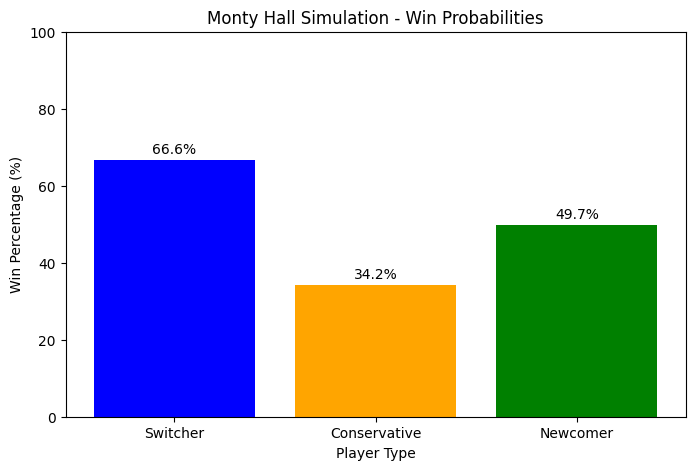

In [8]:
trials = 10000  
N, M = 3, 1  # Classic Monty Hall problem setup with 3 doors and 1 opened by the host

# Run the probability simulation
switcher_win_pct, conservative_win_pct, newcomer_win_pct = simulate_probability(N, M, trials)

# Convert win rates to percentages
win_percentages = [switcher_win_pct * 100, conservative_win_pct * 100, newcomer_win_pct * 100]

# Print the results using formatted strings
print(f"Switcher wins: {win_percentages[0]:.1f}%")
print(f"Conservative wins: {win_percentages[1]:.1f}%")
print(f"Newcomer wins: {win_percentages[2]:.1f}%")

# Plot the probability distribution
categories = ['Switcher', 'Conservative', 'Newcomer']

# Create a bar chart
plt.figure(figsize=(8, 5))
bars = plt.bar(categories, win_percentages, color=['blue', 'orange', 'green'])

plt.xlabel("Player Type")
plt.ylabel("Win Percentage (%)")
plt.title("Monty Hall Simulation - Win Probabilities")
plt.ylim(0, 100)

for bar, pct in zip(bars, win_percentages):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{pct:.1f}%", ha='center', va='bottom')

plt.show()


At the start, the chance the car is behind your chosen door is 1/3. That means there’s a 2/3 chance the car is behind one of the other two doors.

After you pick, the host opens one of the other doors to reveal a goat. This is important because the host always avoids the car.

Now, the door you picked still has a 1/3 chance of hiding the car, but the other unopened door has the full 2/3 chance. So, switching gives you a better chance of winning.

In short:  
- Stay = 1/3 chance  
- Switch = 2/3 chance  

So yes, you should always switch.

If someone walks in after a door was opened and doesn’t know the original choice, they’d think it’s a 50/50 guess. But with full context, switching is clearly better.

### Generalized Monty Hall Problem

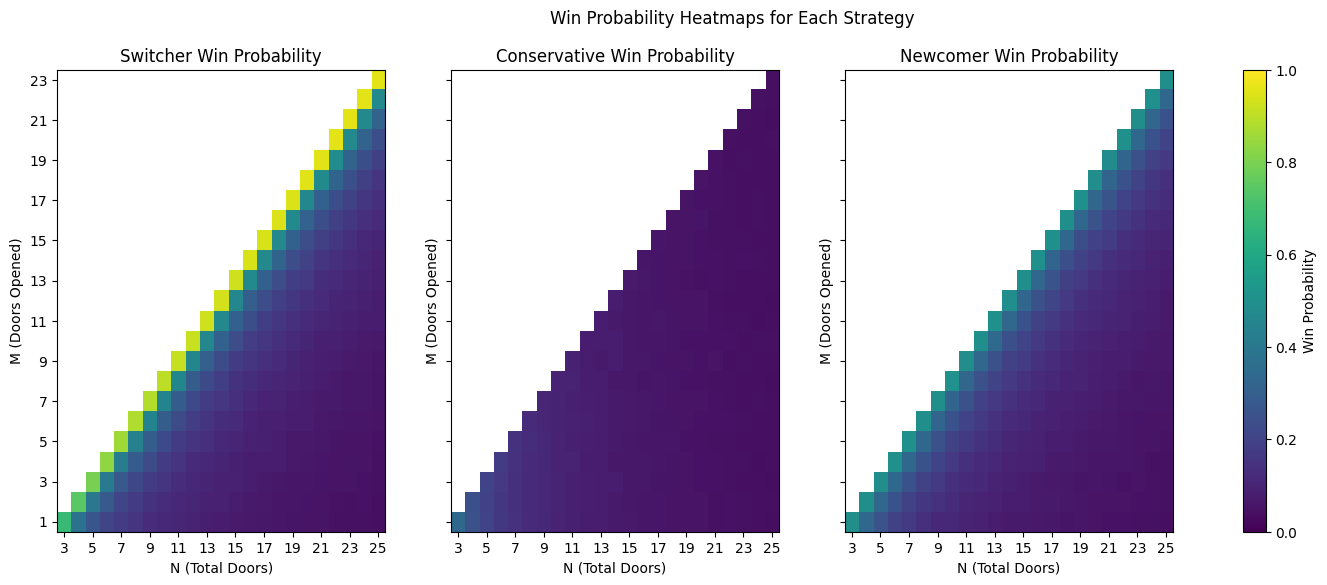

In [11]:
# Create matrices for each strategy
N_max = 25
prob_sw_matrix = np.full((N_max - 2, N_max - 2), np.nan)
prob_cons_matrix = np.full((N_max - 2, N_max - 2), np.nan)
prob_new_matrix = np.full((N_max - 2, N_max - 2), np.nan)

# Fill the matrices
for N in range(3, N_max + 1):
    for M in range(1, N - 1):
        sw, cons, new = simulate_probability(N, M, trials=10000)
        prob_sw_matrix[M - 1, N - 3] = sw
        prob_cons_matrix[M - 1, N - 3] = cons
        prob_new_matrix[M - 1, N - 3] = new

# Set up plot
fig, axs = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True)

titles = ["Switcher", "Conservative", "Newcomer"]
matrices = [prob_sw_matrix, prob_cons_matrix, prob_new_matrix]
vmin = 0
vmax = 1  # Normalize color scale

for ax, data, title in zip(axs, matrices, titles):
    im = ax.imshow(data, origin='lower', aspect='auto', vmin=vmin, vmax=vmax, cmap='viridis')
    ax.set_title(f"{title} Win Probability")
    ax.set_xlabel("N (Total Doors)")
    ax.set_xticks(np.arange(0, N_max - 2, 2))
    ax.set_xticklabels(np.arange(3, N_max + 1, 2))
    ax.set_yticks(np.arange(0, N_max - 2, 2))
    ax.set_yticklabels(np.arange(1, N_max - 1, 2))
    ax.set_ylabel("M (Doors Opened)")

fig.colorbar(im, ax=axs, location='right', label='Win Probability')
plt.suptitle("Win Probability Heatmaps for Each Strategy")
#.tight_layout()
plt.show()

In the generalized Monty Hall problem, the win probability of the player who initially chooses one door, and then switches after $ M $ doors are opened is:  

$$
P_{\text{switch}} = \frac{N - 1}{N} \cdot \frac{1}{N - M - 1}
$$

- The first factor $ \frac{N - 1}{N} $ is the probability the car is not behind the originally chosen door.
- The second factor $ \frac{1}{N - M - 1} $ is the chance of randomly selecting the car from the remaining unopened doors (excluding the one initially chosen and the $ M $ opened by the host).

This expression is always greater than $ \frac{1}{N} $, which is the win rate if you do not switch.  

For the newcomer, the win probability is:

$$
P_{\text{newcomer}} = \frac{1}{N - M}
$$

This player has fewer doors to choose from but doesn’t benefit from knowing which door was originally chosen — so they can't update beliefs in a Bayesian sense. 
They do better than the conservative, but worse than the switcher.

Therefore, switching remains the better strategy no matter how many doors $ N $ or opened doors $ M $ are involved.

From this perspective, visualizations show that choosing like the “switcher” consistently gives the best chance of success.